# Visual analysis of images  (2023)

In [1]:
import random

import pandas as pd
import numpy as np
from tqdm import tqdm
import json

## 1. Read embedding file

In [ ]:
df = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.image', sep='\t')
df.head(5)

,img_id:token,img_emb:float_seq
0,884509,2.116241893624543 -3.0418755567230007 -5.46931...
1,561856,1.649818936829127 3.1124404940420742 2.8051456...
2,239749,-1.578862879367632 -4.014066168838383 0.149213...
3,55030,3.093842411693621 -1.7237219859956285 -0.78452...
4,1277121,-1.2830992703265296 5.067334132483662 1.839873...


## 2. Preprocess embeddings

In [4]:
df.rename(columns={"img_emb:float_seq": "emb", "img_id:token": "id"}, inplace=True)
df["emb"] = df["emb"].apply(lambda x: np.fromstring(x, dtype=np.float32, sep=' '))
df.head(5)

,id,emb
0,884509,"[2.116242, -3.0418756, -5.469318, 0.9049815, -..."
1,561856,"[1.6498189, 3.1124406, 2.8051457, -1.02009, -1..."
2,239749,"[-1.5788629, -4.014066, 0.14921321, 1.5560805,..."
3,55030,"[3.0938425, -1.723722, -0.78452605, -1.4718788..."
4,1277121,"[-1.2830993, 5.067334, 1.8398732, 0.92253864, ..."


## 3. Fit KNN with static embeddings

In [5]:
from sklearn.neighbors import NearestNeighbors

X = np.vstack(df["emb"].values)
knn = NearestNeighbors(n_neighbors=10, metric='cosine')
knn.fit(X)

NearestNeighbors(metric='cosine', n_neighbors=10)

## 4. Take random item and find its neighbours

In [6]:
import random

n_ids = df["id"].shape[0]

while True:
    random_idx = random.choice(range(n_ids))

    if sum(X[random_idx]) != 0:
        break

orig_id = df["id"].iloc[random_idx]

dist, nearest_ids = knn.kneighbors([X[random_idx]])

## 5. Convert into correct metadata

In [ ]:
ids = nearest_ids[0]
distances = dist[0]

# Read the mappings
with open('../../../Amazon_Sports_and_Outdoors/item_mapping_Amazon_Sports_and_Outdoors.json', encoding='utf-8') as f:
    asin_mapping = json.load(f)

parent_asins = [asin_mapping[idx] for idx in ids]
print(parent_asins[:10])

['B00LG6C22G', 'B07L47RVNQ', 'B001FVLKHA', 'B07SR2FLYV', 'B0B6M1ND7S', 'B002FMGX1Q', 'B001B83OYO', 'B08F1ZCL9S', 'B002JH9FAS', 'B07TPBQYR6']


In [ ]:
data = {}
orig_img_url = ''
with open('../../../Amazon_Sports_and_Outdoors/meta_Sports_and_Outdoors.jsonl') as f:
    for line in f:
        entry = json.loads(line)

        images_list = entry['images']

        if entry['parent_asin'] == asin_mapping[orig_id]:
            orig_img_url = images_list[0].get('large', None)
            continue

        if len(images_list) == 0 or entry['parent_asin'] not in parent_asins:
            continue

        data[entry['parent_asin']] = images_list[0].get('large', None)

## 6. Visual analysis

### 6.1 Original image

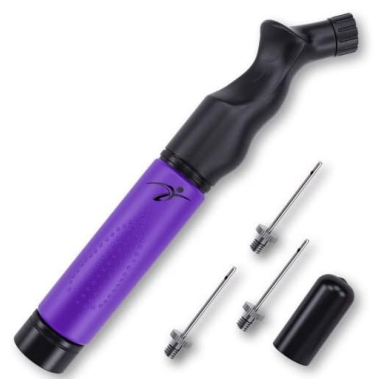

In [9]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

response = requests.get(orig_img_url, stream=True)
response.raise_for_status()

img = Image.open(BytesIO(response.content))
plt.imshow(img)
plt.axis('off')
plt.show()

### 6.2 Supposedly similar images (sorted by distance)

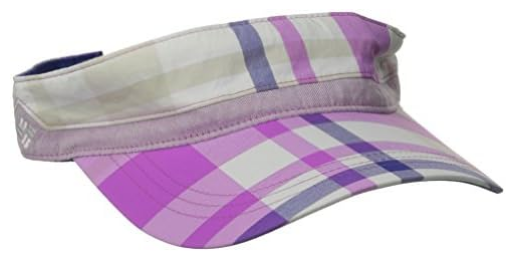

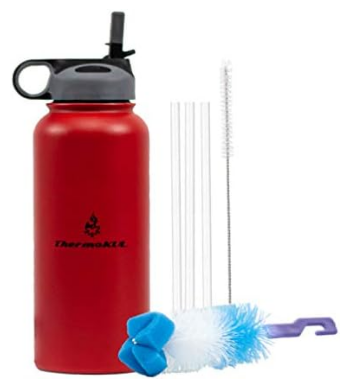

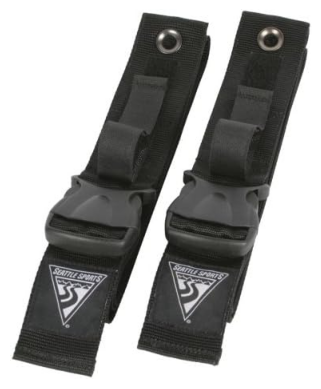

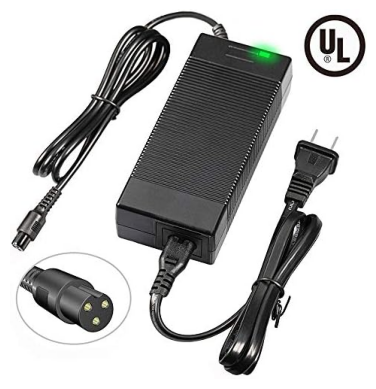

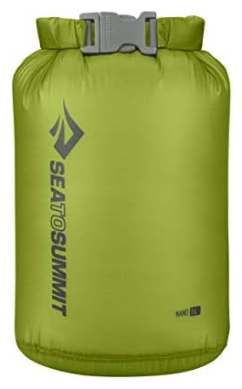

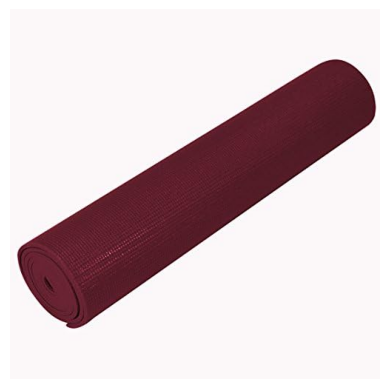

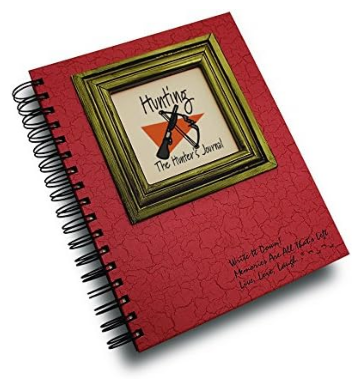

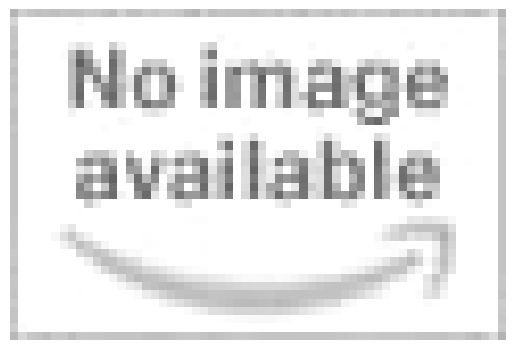

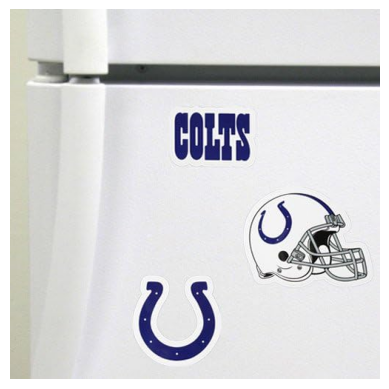

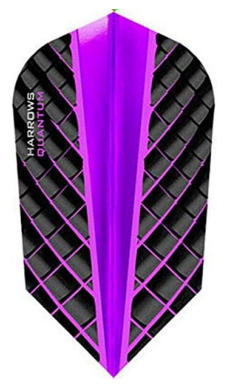

In [10]:
for parent_asin in parent_asins:
    response = requests.get(data[parent_asin], stream=True)
    response.raise_for_status()

    img = Image.open(BytesIO(response.content))
    plt.imshow(img)
    plt.axis('off')
    plt.show()